# Part 4 — Vector Databases: Embedding & Similarity

This notebook demonstrates:
- Generating sentence embeddings using `sentence-transformers` (`all-MiniLM-L6-v2`)
- Computing a 10×10 cosine similarity matrix and visualizing it as a heatmap
- Finding the top 2 most similar sentences to a new query

**Topics covered:** Cricket, Cooking, Cybersecurity (≥3 sentences each)

In [1]:
# Install required libraries (run once in Colab)
!pip install sentence-transformers -q
!pip install seaborn -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# ── 10 sentences across 3 topics ──────────────────────────────
# Cricket (4 sentences), Cooking (3 sentences), Cybersecurity (3 sentences)

sentences = [
    # Cricket
    "The batsman scored a brilliant century in the final test match.",        # 0
    "India won the series after an exciting last-over finish.",               # 1
    "The spin bowler deceived the batsman with a well-disguised googly.",     # 2
    "A dropped catch in the slips changed the entire course of the game.",   # 3

    # Cooking
    "Slow cooking the curry on a low flame brings out the deep flavours.",   # 4
    "Marinating the chicken overnight in yoghurt makes it tender and juicy.",# 5
    "A pinch of garam masala at the end elevates any Indian dish.",          # 6

    # Cybersecurity
    "Phishing emails trick users into revealing their login credentials.",   # 7
    "Using a strong, unique password for every account reduces breach risk.",# 8
    "A firewall monitors and controls incoming and outgoing network traffic.",# 9
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1",   "Cyber-2",   "Cyber-3"
]

print(f'Total sentences: {len(sentences)}')
for i, s in enumerate(sentences):
    print(f'  [{i}] {s}')

Total sentences: 10
  [0] The batsman scored a brilliant century in the final test match.
  [1] India won the series after an exciting last-over finish.
  [2] The spin bowler deceived the batsman with a well-disguised googly.
  [3] A dropped catch in the slips changed the entire course of the game.
  [4] Slow cooking the curry on a low flame brings out the deep flavours.
  [5] Marinating the chicken overnight in yoghurt makes it tender and juicy.
  [6] A pinch of garam masala at the end elevates any Indian dish.
  [7] Phishing emails trick users into revealing their login credentials.
  [8] Using a strong, unique password for every account reduces breach risk.
  [9] A firewall monitors and controls incoming and outgoing network traffic.


In [4]:
# ── Load the model and generate embeddings ────────────────────
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print(f'Embedding shape: {embeddings.shape}')  # Should be (10, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [5]:
# ── Compute 10×10 cosine similarity matrix ────────────────────
sim_matrix = cosine_similarity(embeddings)

print('Cosine Similarity Matrix (10×10):')
print(np.round(sim_matrix, 3))

Cosine Similarity Matrix (10×10):
[[ 1.     0.501  0.437  0.172  0.106  0.042  0.156 -0.011  0.021  0.065]
 [ 0.501  1.     0.302  0.099  0.151  0.002  0.221 -0.019 -0.041  0.086]
 [ 0.437  0.302  1.     0.236  0.202  0.051  0.185  0.18   0.058  0.044]
 [ 0.172  0.099  0.236  1.     0.092 -0.014  0.095  0.084  0.062  0.088]
 [ 0.106  0.151  0.202  0.092  1.     0.27   0.291  0.086  0.065  0.093]
 [ 0.042  0.002  0.051 -0.014  0.27   1.     0.184  0.023  0.046 -0.046]
 [ 0.156  0.221  0.185  0.095  0.291  0.184  1.    -0.011 -0.055  0.064]
 [-0.011 -0.019  0.18   0.084  0.086  0.023 -0.011  1.     0.467  0.077]
 [ 0.021 -0.041  0.058  0.062  0.065  0.046 -0.055  0.467  1.     0.015]
 [ 0.065  0.086  0.044  0.088  0.093 -0.046  0.064  0.077  0.015  1.   ]]


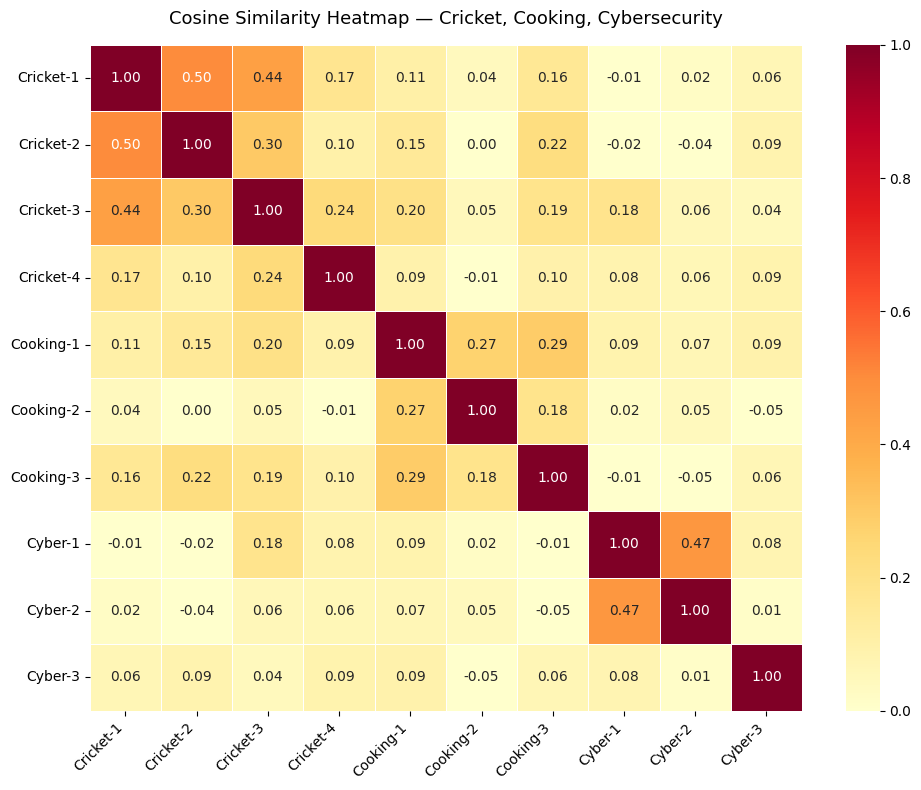

Heatmap saved as similarity_heatmap.png


In [6]:
# ── Visualize the matrix as a heatmap ────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5
)
plt.title('Cosine Similarity Heatmap — Cricket, Cooking, Cybersecurity', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()
print('Heatmap saved as similarity_heatmap.png')

In [7]:
# ── Query: find top 2 most similar sentences ─────────────────
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])   # shape: (1, 384)
query_scores    = cosine_similarity(query_embedding, embeddings)[0]  # shape: (10,)

# Rank sentences by similarity score (descending)
ranked_indices = np.argsort(query_scores)[::-1]

print(f'Query: "{query}"')
print()
print('Top 2 most similar sentences:')
for rank, idx in enumerate(ranked_indices[:2], start=1):
    print(f'  Rank {rank}: [{labels[idx]}] "{sentences[idx]}"')
    print(f'           Similarity score: {query_scores[idx]:.4f}')
    print()

Query: "The bowler took three wickets in one over"

Top 2 most similar sentences:
  Rank 1: [Cricket-1] "The batsman scored a brilliant century in the final test match."
           Similarity score: 0.5323

  Rank 2: [Cricket-3] "The spin bowler deceived the batsman with a well-disguised googly."
           Similarity score: 0.5032

